### 5.1 Build the Panel Dataset

This block loads all player-count and sentiment CSVs, matches each game's two files by week, and combines them into one stacked panel (`panel_df`).
The result is a game-week dataset where each row represents one game in one week with both activity and sentiment variables available for analysis.


In [1]:
import os
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

data_path = "/Users/user/Desktop/math189/Data/189 Project Data"

files = os.listdir(data_path)

games = sorted(set(
    f.replace("_players.csv", "").replace("_sentiment.csv", "")
    for f in files
    if f.endswith(".csv")
))

dfs = []
for game in games:
    players_fp = os.path.join(data_path, f"{game}_players.csv")
    sent_fp    = os.path.join(data_path, f"{game}_sentiment.csv")

    players = pd.read_csv(players_fp)
    sent    = pd.read_csv(sent_fp)

    df = players.merge(sent, on="week", how="inner")
    df["game"] = game
    dfs.append(df)

panel_df = pd.concat(dfs, ignore_index=True)

print("Games:", panel_df["game"].nunique(), "| Rows:", len(panel_df))
print(panel_df.columns)
panel_df.head()

Games: 15 | Rows: 4123
Index(['week', 'players', 'log_players', 'neg_sentiment', 'pos_sentiment',
       'n_posts', 'game'],
      dtype='object')


,week,players,log_players,neg_sentiment,pos_sentiment,n_posts,game
0,2020-01-06,85298,11.353906,0.091221,0.908779,2480.25,ARK Survival Evolved
1,2020-01-13,85329,11.354270,0.091221,0.908779,2480.25,ARK Survival Evolved
2,2020-01-20,85385,11.354926,0.091221,0.908779,2480.25,ARK Survival Evolved
3,2020-01-27,85471,11.355932,0.091221,0.908779,2480.25,ARK Survival Evolved
4,2020-02-03,85591,11.357335,0.126786,0.873214,2204.50,ARK Survival Evolved


### 5.2 Cleaning and Preproscessing

This step standardizes dates, restricts the analysis window (2020–2024), and constructs a cleaned player metric (`log_players_clean`).
I treat placeholder or implausible values (very low player counts and extreme one-week crashes) as missing, then linearly interpolate within each game to recover smooth weekly series.

Using a full weekly grid ensures all games are aligned on the same timeline before stratification and modeling.


In [2]:

panel_df = panel_df.copy()
panel_df["week"] = pd.to_datetime(panel_df["week"])
panel_df = panel_df.sort_values(["game", "week"])

#cap tje time period
start = pd.Timestamp("2020-01-01")
end   = pd.Timestamp("2024-09-30")
panel_df = panel_df[(panel_df["week"] >= start) & (panel_df["week"] <= end)].copy()

#add a cleaned play column
panel_df["log_players_clean"] = panel_df["log_players"]

#replace placeholder entries with NaN
panel_df.loc[panel_df["players"] <= 1, "log_players_clean"] = np.nan

#full weekly grids
full_weeks = pd.date_range("2020-01-06", "2024-12-30", freq="W-MON")

panel_df = (
    panel_df.set_index(["game", "week"])
            .groupby(level=0)
            .apply(lambda g: g.droplevel(0).reindex(full_weeks))
)
panel_df.index.names = ["game", "week"]
panel_df = panel_df.reset_index()

panel_df = panel_df.sort_values(["game", "week"])

#interpolation 1
panel_df["log_players_clean"] = panel_df.groupby("game")["log_players_clean"].transform(
    lambda s: s.interpolate(method="linear", limit_direction="both")
)

# --- crash/outlier rules ---
panel_df["dlog"] = panel_df.groupby("game")["log_players_clean"].diff()

# big one-week crashes
panel_df.loc[panel_df["dlog"] < -2, "log_players_clean"] = np.nan

# suspiciously tiny raw counts (catches players=11 etc.)
panel_df.loc[panel_df["players"] < 100, "log_players_clean"] = np.nan

#final interpolation
panel_df["log_players_clean"] = panel_df.groupby("game")["log_players_clean"].transform(
    lambda s: s.interpolate(method="linear", limit_direction="both")
)

### 5.3 Construct Game Strata (Popular, Decline, Volatile)

Here I compute per-game summary metrics:
- average log player level (`mean_log`)
- linear trend over time (`slope`)
- week-to-week volatility in player changes (`vol_dlog`)

Games are then assigned to three strata using a 5/5/remaining split:
- **Decline**: 5 games with the most negative slopes
- **Popular**: 5 highest-average games among the remaining set
- **Volatile**: all remaining games

This creates interpretable groups for comparative EDA.


In [3]:
panel_df = panel_df.dropna(subset=["log_players_clean"])
panel_df = panel_df.sort_values(["game", "week"]).copy()

panel_df["t"] = panel_df.groupby("game").cumcount()

def game_metrics(g):
    y = g["log_players_clean"].to_numpy()
    t = g["t"].to_numpy()

    t_c = t - t.mean()
    y_c = y - y.mean()
    slope = (t_c @ y_c) / (t_c @ t_c)

    dy = np.diff(y)
    vol = np.std(dy) if len(dy) > 1 else np.nan

    return pd.Series({
        "mean_log": np.mean(y),
        "slope": slope,
        "vol_dlog": vol,
        "n_weeks": len(y)
    })

metrics = panel_df.groupby("game").apply(game_metrics).reset_index()

# 5/5/5 split
decline_games = metrics.nsmallest(5, "slope")["game"].tolist()
remaining = metrics[~metrics["game"].isin(decline_games)].copy()

popular_games = remaining.nlargest(5, "mean_log")["game"].tolist()
volatile_games = remaining[~remaining["game"].isin(popular_games)]["game"].tolist()

label_map = {g: "popular" for g in popular_games}
label_map.update({g: "decline" for g in decline_games})
label_map.update({g: "volatile" for g in volatile_games})

panel_df["stratum"] = panel_df["game"].map(label_map)

print(panel_df["stratum"].value_counts())


stratum
decline     1305
popular     1305
volatile    1305
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_19772\606038060.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = panel_df.groupby("game").apply(game_metrics).reset_index()


In [4]:
sus = panel_df[panel_df["dlog"] < -2][["game", "week", "log_players_clean", "dlog"]]
print("Suspicious drops remaining:", len(sus))
display(sus.sort_values(["game", "week"]).head(20))

Suspicious drops remaining: 1


,game,week,log_players_clean,dlog
2910,Rainbow Six Siege,2020-10-05,8.263365,-5.916447


To validate the cleaning step, I check whether any extreme one-week drops (`dlog < -2`) remain after interpolation and outlier filtering.
This is a sanity check to confirm major data artifacts were removed before plotting and correlation analysis.


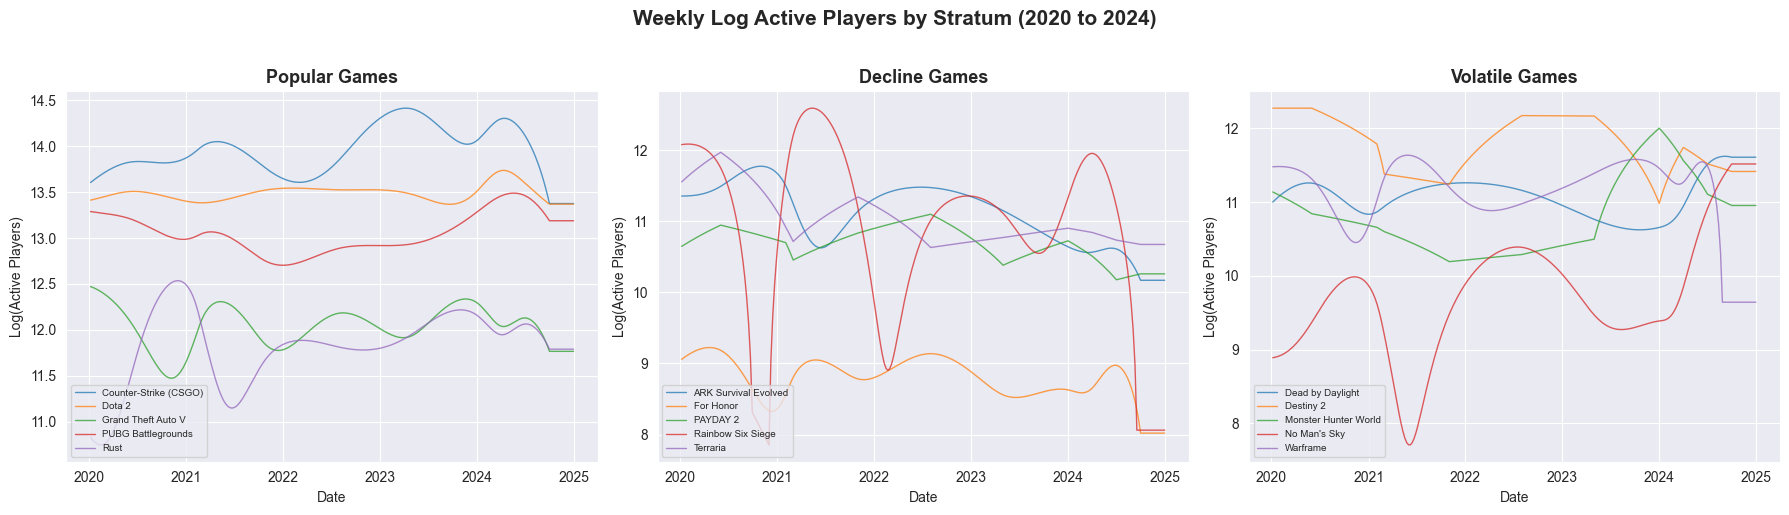

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, stratum in zip(axes, ["popular", "decline", "volatile"]):
    sub = panel_df[panel_df["stratum"] == stratum]

    for game in sub["game"].dropna().unique():
        g = sub[sub["game"] == game]
        ax.plot(g["week"], g["log_players_clean"], alpha=0.75, label=game, linewidth=1.0)

    ax.set_title(f"{stratum.capitalize()} Games", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Log(Active Players)")
    ax.legend(fontsize=7, loc="lower left")

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Weekly Log Active Players by Stratum (2020 to 2024)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The figure above plots weekly log player trajectories separately for popular, decline, and volatile strata.
Viewing all games within each group helps verify that the stratification reflects distinct behavioral patterns (persistent high levels, downward trends, or unstable movement) rather than arbitrary labels.


### 5.4 Descriptive Patterns by Stratum


C:\Users\user\AppData\Local\Temp\ipykernel_19772\3332414135.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=[s.capitalize() for s in strata], showfliers=False)


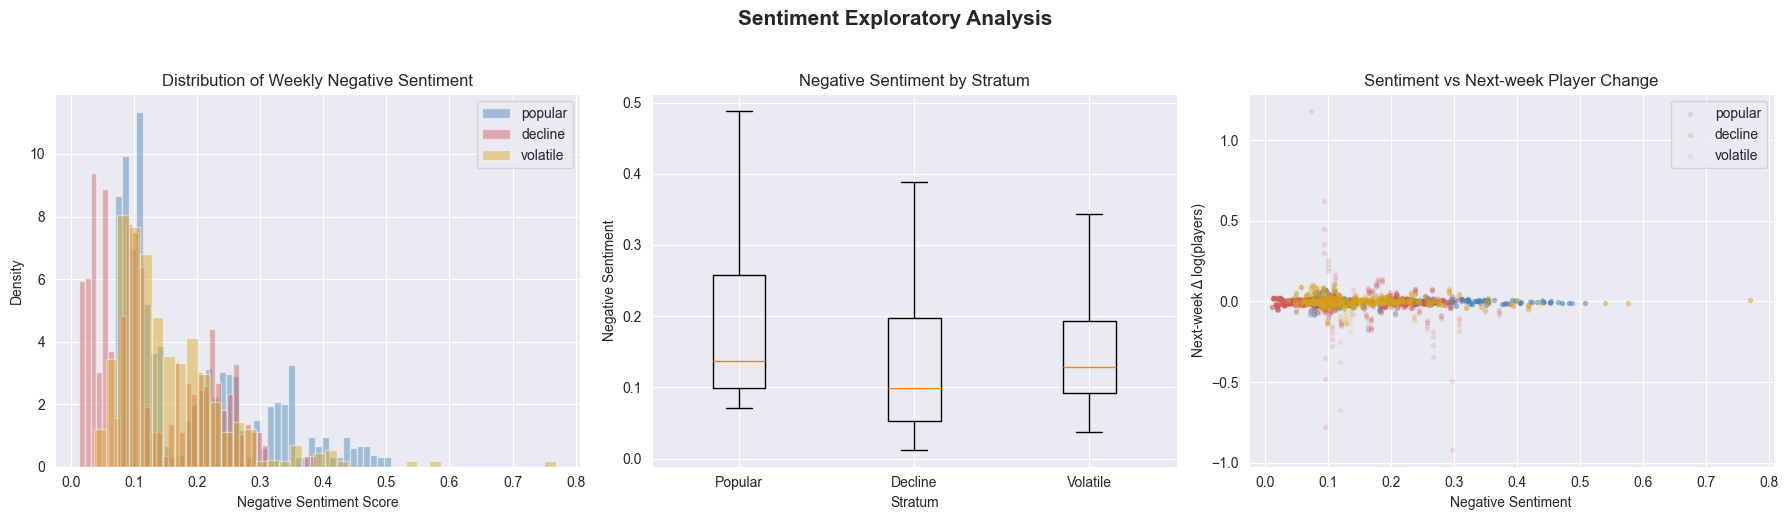

In [6]:
plot_df = panel_df.dropna(subset=["neg_sentiment", "log_players_clean", "stratum"]).copy()
plot_df = plot_df.sort_values(["game", "week"])

# compute next-week player change
plot_df["player_change_next"] = plot_df.groupby("game")["log_players_clean"].diff().shift(-1)

plot_df = plot_df.dropna(subset=["player_change_next"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strata = ["popular", "decline", "volatile"]
colors = {"popular": "steelblue", "decline": "indianred", "volatile": "goldenrod"}

#density histogram for negative sentiment

for s in strata:
    sub = plot_df[plot_df["stratum"] == s]["neg_sentiment"]
    axes[0].hist(sub, bins=40, alpha=0.45, density=True, color=colors[s], label=s)

axes[0].set_xlabel("Negative Sentiment Score")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of Weekly Negative Sentiment")
axes[0].legend()

# box plot of begative sentiment by stratum

data = [plot_df.loc[plot_df["stratum"] == s, "neg_sentiment"].values for s in strata]
axes[1].boxplot(data, labels=[s.capitalize() for s in strata], showfliers=False)
axes[1].set_title("Negative Sentiment by Stratum")
axes[1].set_xlabel("Stratum")
axes[1].set_ylabel("Negative Sentiment")

#scatter plot of negative sentiment vs next-week player chahnge

for s in strata:
    sub = plot_df[plot_df["stratum"] == s]

    axes[2].scatter(
        sub["neg_sentiment"],
        sub["player_change_next"],
        alpha=0.12,
        s=8,
        color=colors[s],
        label=s
    )

axes[2].set_xlabel("Negative Sentiment")
axes[2].set_ylabel("Next-week Δ log(players)")
axes[2].set_title("Sentiment vs Next-week Player Change")
axes[2].legend()

fig.suptitle("Sentiment Exploratory Analysis", fontsize=15, fontweight="bold", y=1.03)

plt.tight_layout()
plt.show()

The left panel shows the distribution of weekly negative sentiment scores across the three game groups.
Popular games tend to have a wider sentiment distribution and more extreme negative sentiment values, reflecting higher discussion amount and more polarized player reactions.
Declining games show lower and more concentrated negative sentiment levels, while volatile games lie somewhere in between but shows occasional high-sentiment spikes.
Overall, negative sentiment across all groups is generally low, with most observations clustered around 0.05–0.20.

The middle panel summarizes the sentiment distribution using boxplots.
Popular and volatile games show higher median negative sentiment compared to declining games.
Popular games also exhibit the largest spread, suggesting that player discussions fluctuate more dramatically for games with larger player bases.
In contrast, declining games tend to have lower sentiment intensity and less variability.

The right panel examines whether negative sentiment is associated with changes in player counts in the following week.
Each point represents a game-week observation, with sentiment on the horizontal axis and the next week’s change in log player counts on the vertical axis.
While the relationship appears noisy, higher negative sentiment values are occasionally associated with larger declines in player counts.
However, the overall relationship is weak in raw data, which suggest a more formal regression analysis controlling for game-sentiment relationship.

### 5.5 Time Series Visualization: Sentiment and Players for a Single Game

In [7]:
# games = [
#     "Counter-Strike (CSGO)",
#     "ARK Survival Evolved",
#     "No Man's Sky"
# ]
#
# fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
#
# for i, game in enumerate(games):
#
#     sub = panel_df[panel_df["game"] == game].sort_values("week")
#
#     # players
#     axes[i,0].plot(sub["week"], sub["log_players_clean"], color="steelblue")
#     axes[i,0].set_title(f"{game} — Player Activity")
#     axes[i,0].set_ylabel("Log Players")
#
#     # sentiment
#     axes[i,1].plot(sub["week"], sub["neg_sentiment"], color="indianred")
#     axes[i,1].set_title(f"{game} — Negative Sentiment")
#     axes[i,1].set_ylabel("Neg Sentiment")
#
# axes[2,0].set_xlabel("Week")
# axes[2,1].set_xlabel("Week")
#
# fig.suptitle("Player Activity and Sentiment Over Time", fontsize=16)
#
# plt.tight_layout()
# plt.show()

#THIS HAVE THE PLAYER ACTIVITY AND NEGATIVE SENTIMENT NEXT TO EACH OTHER, NEXT CODE BLOCK HAVE THEM OVERLAY

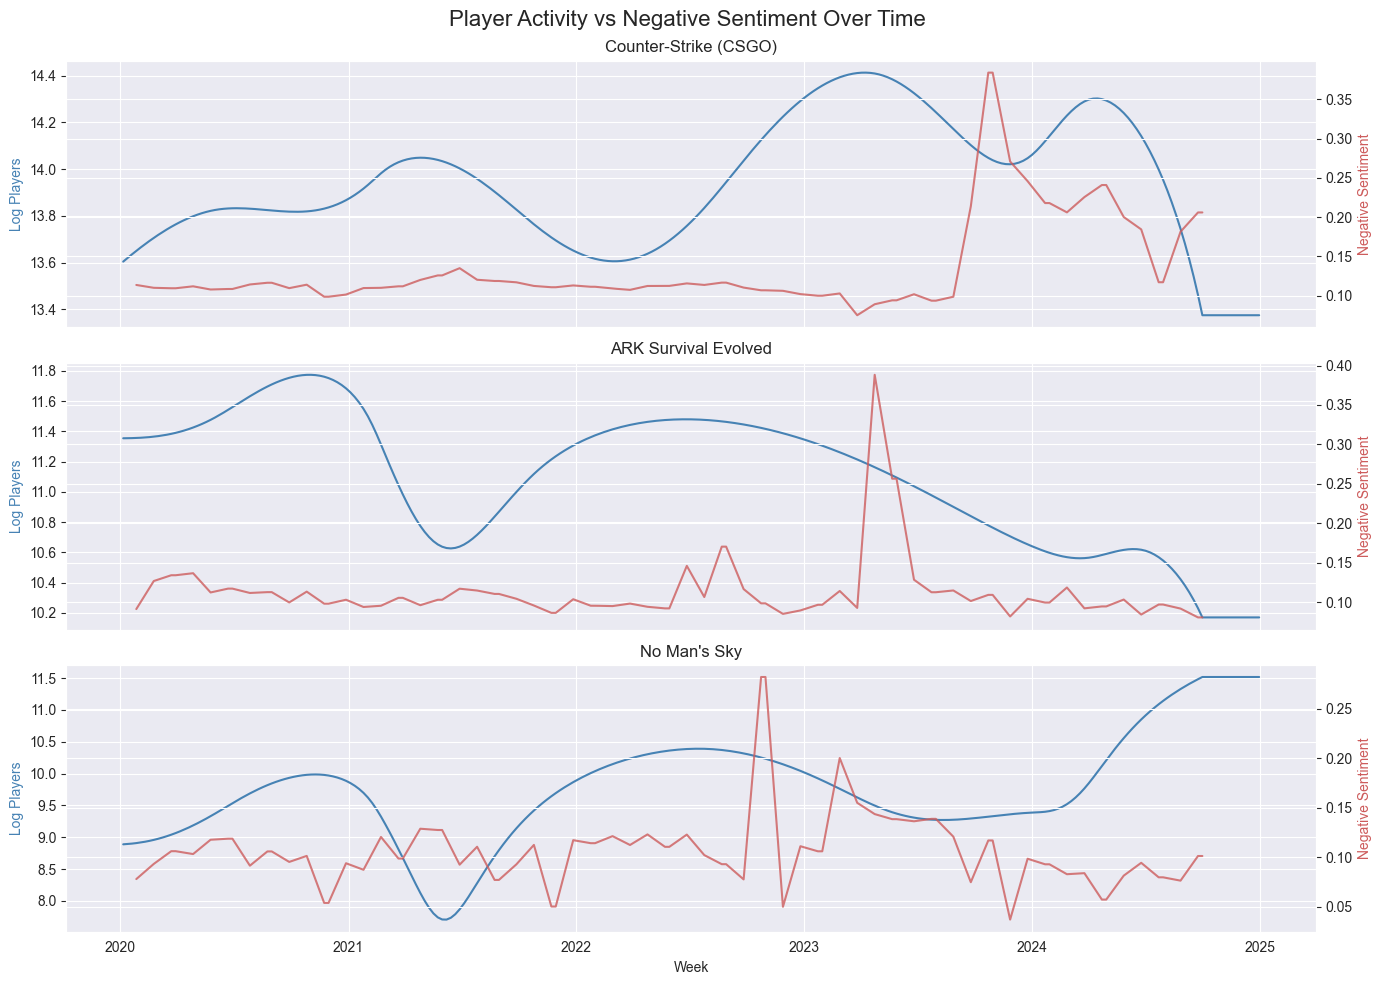

In [8]:
games = [
    "Counter-Strike (CSGO)",
    "ARK Survival Evolved",
    "No Man's Sky"
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, game in enumerate(games):

    sub = panel_df[panel_df["game"] == game].sort_values("week").copy()

    # smooth sentiment slightly (optional but recommended)
    sub["sentiment_ma"] = sub["neg_sentiment"].rolling(4).mean()

    ax1 = axes[i]

    # player counts
    ax1.plot(sub["week"], sub["log_players_clean"],
             color="steelblue", label="Log Players")
    ax1.set_ylabel("Log Players", color="steelblue")

    # sentiment axis
    ax2 = ax1.twinx()

    ax2.plot(sub["week"], sub["sentiment_ma"],
             color="indianred", alpha=0.8, label="Neg Sentiment (4wk MA)")
    ax2.set_ylabel("Negative Sentiment", color="indianred")

    ax1.set_title(game)

axes[-1].set_xlabel("Week")

fig.suptitle("Player Activity vs Negative Sentiment Over Time", fontsize=16)

plt.tight_layout()
plt.show()

For Counter-Strike, player activity remains relatively stable and even increases over the sample period, reflecting its large and persistent player base. Negative sentiment fluctuates over time and occasionally spikes, but these spikes do not appear to produce large immediate declines in players. This suggests that highly popular games may be more resilient to negative discussion in the community.
ARK shows a gradual downward trend in player activity over time. Negative sentiment remains relatively low for most weeks but occasionally spikes. These sentiment spikes sometimes occur around periods of declining player activity, though the relationship is not visually strong.
No Man’s Sky displays larger fluctuations in both player activity and sentiment. Player counts show several periods of sharp increases and declines, while sentiment spikes appear around some of these volatile periods. This suggests that games with more volatile communities may exhibit stronger links between sentiment shocks and player activity changes.

From the three chosen games we can see that while sentiment spikes occasionally to line up with changes in player activity, the relationship appears noisy in the raw time series. This motivates the use of regression models to formally test whether negative sentiment predicts future changes in player counts.

### 5.5 Cross Correlation Analysis

We compute the cross correlation function (CCF) between $\Delta \log(\text{players})$ and $\text{neg\_sentiment}$ at various lags. If we see a significant negative correlation at lag $k > 0$, that is suggestive (though not proof) that sentiment leads player declines. The dashed lines on the plots below mark the 95% confidence band under the null of no correlation, so bars that poke past those lines are the ones worth paying attention to.

In [9]:
panel_df = panel_df.sort_values(["game", "week"])

panel_df["dlog_players"] = panel_df.groupby("game")["log_players_clean"].diff()

In [10]:
def cross_corr(x, y, max_lag=20):
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()

    lags = np.arange(-max_lag, max_lag+1)
    corrs = []

    for lag in lags:

        if lag < 0:
            corr = np.corrcoef(x[:lag], y[-lag:])[0,1]
        elif lag > 0:
            corr = np.corrcoef(x[lag:], y[:-lag])[0,1]
        else:
            corr = np.corrcoef(x, y)[0,1]

        corrs.append(corr)

    return lags, corrs

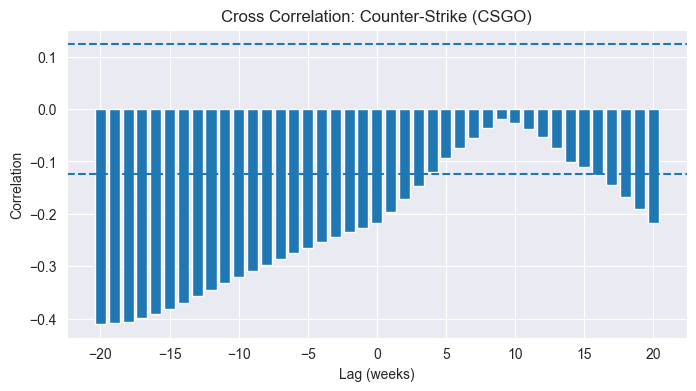

In [11]:
game = "Counter-Strike (CSGO)"

sub = panel_df[panel_df["game"] == game].dropna(subset=["dlog_players","neg_sentiment"])

x = sub["dlog_players"].values
y = sub["neg_sentiment"].values

lags, corrs = cross_corr(x, y, max_lag=20)

plt.figure(figsize=(8,4))
plt.bar(lags, corrs)

conf = 1.96/np.sqrt(len(sub))

plt.axhline(conf, linestyle="--")
plt.axhline(-conf, linestyle="--")

plt.title(f"Cross Correlation: {game}")
plt.xlabel("Lag (weeks)")
plt.ylabel("Correlation")

plt.show()

For Counter-Strike, correlations are mostly negative and several exceed the confidence bounds, particularly at negative lags. This suggests that declines in player activity may precede increases in negative sentiment rather than the other way around. In other words, players may become more negative after activity drops rather than sentiment causing the drop.

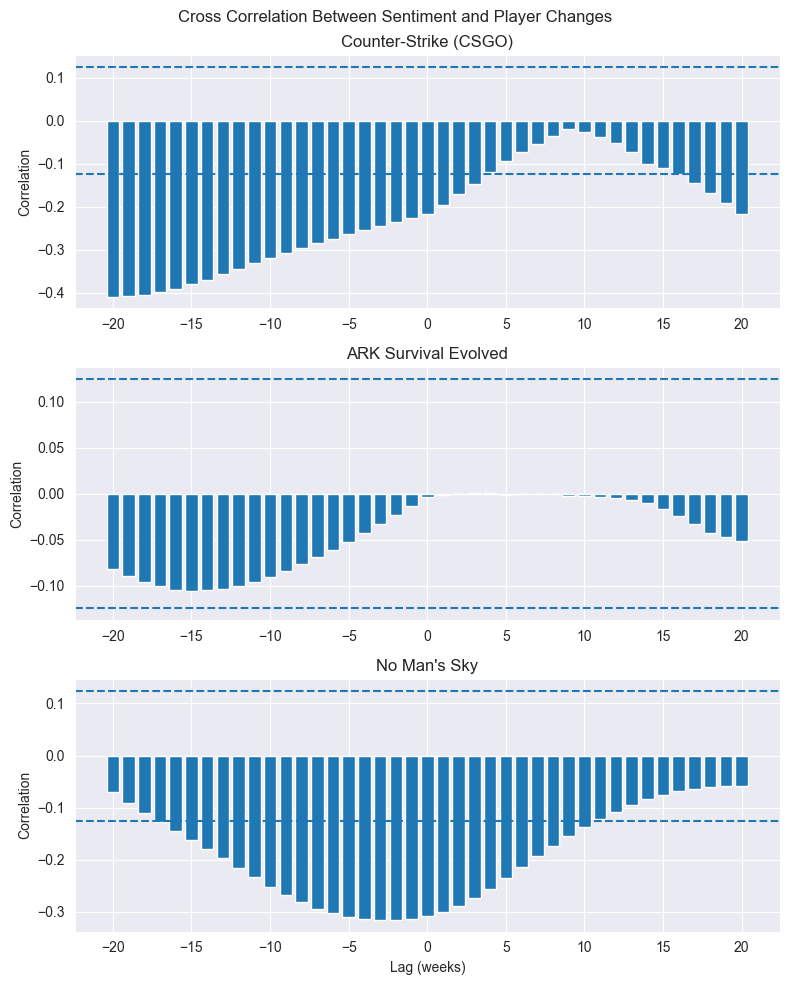

In [12]:
games = [
    "Counter-Strike (CSGO)",
    "ARK Survival Evolved",
    "No Man's Sky"
]

fig, axes = plt.subplots(3,1, figsize=(8,10))

for i, game in enumerate(games):

    sub = panel_df[panel_df["game"] == game].dropna(subset=["dlog_players","neg_sentiment"])

    x = sub["dlog_players"].values
    y = sub["neg_sentiment"].values

    lags, corrs = cross_corr(x,y, max_lag=20)

    axes[i].bar(lags, corrs)

    conf = 1.96/np.sqrt(len(sub))

    axes[i].axhline(conf, linestyle="--")
    axes[i].axhline(-conf, linestyle="--")

    axes[i].set_title(game)
    axes[i].set_ylabel("Correlation")

axes[-1].set_xlabel("Lag (weeks)")

plt.suptitle("Cross Correlation Between Sentiment and Player Changes")

plt.tight_layout()
plt.show()

For ARK, the correlations are relatively small and remain within the confidence bands for most lags. This suggests little systematic relationship between weekly sentiment fluctuations and changes in player activity.
For No Man’s Sky, correlations are larger in magnitude and several exceed the confidence bounds. The correlations are mostly negative, suggesting that higher negative sentiment may be associated with subsequent decreases in player activity. However, the relationship remains noisy and varies across lags.

Overall, the cross-correlation results suggest that the relationship between sentiment and player activity differs across game types. For highly popular games, sentiment appears to respond to changes in player activity rather than driving them. For declining games, sentiment shows little systematic relationship with player trends. In contrast, more volatile games exhibit stronger correlations, suggesting that sentiment shocks may play a larger role in short-term player fluctuations. Because both sentiment and player activity may exhibit autocorrelation, these correlations should be interpreted as suggestive rather than causal.

### 5.6 Correlation Matrix of Panel Variables

we will compute the correlation between negative sentiment and changes in player counts separately for each game. This allows us to focus on within-game relationships over time rather than differences between games.

In [13]:
corrs = []

for game, g in panel_df.groupby("game"):

    g = g.dropna(subset=["neg_sentiment","dlog_players"])

    if len(g) > 20:
        r = g["neg_sentiment"].corr(g["dlog_players"])
        corrs.append(r)

corrs = np.array(corrs)

print("Average within-game correlation:", corrs.mean())
print("Median within-game correlation:", np.median(corrs))

Average within-game correlation: -0.13644928050176494
Median within-game correlation: -0.16797919261467079


On average, higher negative sentiment is associated with decreases in player activity within games. However, the correlations are relatively small in magnitude, suggesting that sentiment explains only a modest portion of short-run player fluctuations.

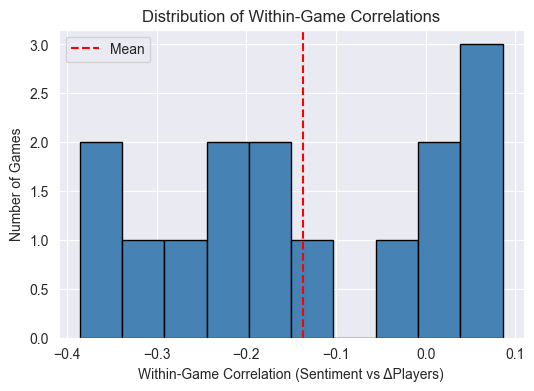

In [14]:
plt.figure(figsize=(6,4))

plt.hist(corrs, bins=10, color="steelblue", edgecolor="black")

plt.axvline(np.mean(corrs), color="red", linestyle="--", label="Mean")

plt.xlabel("Within-Game Correlation (Sentiment vs ΔPlayers)")
plt.ylabel("Number of Games")

plt.title("Distribution of Within-Game Correlations")

plt.legend()
plt.show()

The distribution is centered slightly below zero, indicating that negative sentiment tends to coincide with declines in player counts for many games. However, the spread of the distribution shows that this relationship varies across games and is not uniformly strong.

### 5.7 Conditional Probability Analysis

To express the hypothesis in simple probability terms, we define a **decline** as a negative change in log player counts from week $t$ to week $t+1$:

$$
\Delta \log(\text{players})_{t+1} < 0
$$

We then divide observations into **high** and **low** negative sentiment weeks using the sample median of the sentiment score $\text{neg\_sentiment}_t$. We compare the conditional probabilities:

$$
P(\text{decline}_{t+1}=1 \mid \text{neg\_sentiment}_t > \text{median})
\quad \text{vs.} \quad
P(\text{decline}_{t+1}=1 \mid \text{neg\_sentiment}_t \le \text{median})
$$

These probabilities are summarized in a $2\times2$ contingency table that records whether a decline occurs in the following week under high versus low sentiment conditions. To evaluate whether the difference between these probabilities is statistically meaningful, we perform a **chi-squared test for independence**.


Contingency Table: Sentiment Level vs. Player Decline Next Week
                            No Decline  Decline Next Week  Total
Low Negativity (≤ median)          993                869   1862
High Negativity (> median)         837               1021   1858
Total                             1830               1890   3720

Conditional Probabilities:
  P(decline next week | high negativity) = 0.5495
  P(decline next week | low  negativity) = 0.4667
  Difference (high - low)                = 0.0828

Chi-Squared Test for Independence:
  χ²(1) = 25.1882
  p-value        = 0.000001
  Reject independence: sentiment and next-week declines are associated.


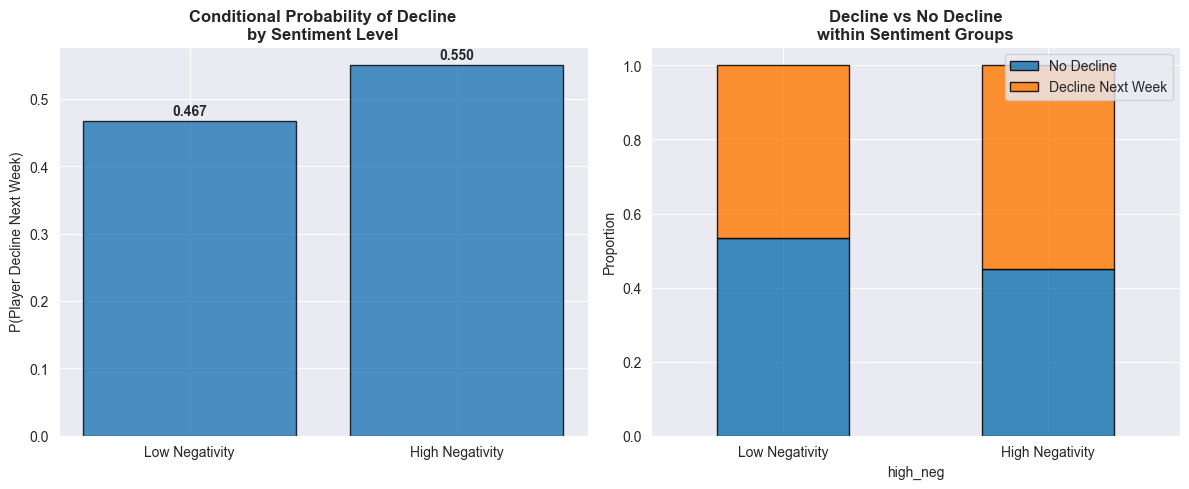

In [15]:

panel_cp = panel_df.copy()
panel_cp = panel_cp.sort_values(["game", "week"])

# define next-week decline
# dlog_players_next = log_players_clean_{t+1} - log_players_clean_{t}
panel_cp["dlog_players_next"] = panel_cp.groupby("game")["log_players_clean"].shift(-1) - panel_cp["log_players_clean"]
panel_cp["decline_next"] = panel_cp["dlog_players_next"] < 0

# Keep rows where decline_next is defined and sentiment exists
panel_cp = panel_cp.dropna(subset=["neg_sentiment", "decline_next"])

#Split into high vs low negative sentiment
median_sent = panel_cp["neg_sentiment"].median()
panel_cp["high_neg"] = panel_cp["neg_sentiment"] > median_sent

#Contingency table (counts)
ct = pd.crosstab(panel_cp["high_neg"], panel_cp["decline_next"], margins=True, margins_name="Total")

#Label it nice
ct.index = ["Low Negativity (≤ median)", "High Negativity (> median)", "Total"]
ct.columns = ["No Decline", "Decline Next Week", "Total"]

print("Contingency Table: Sentiment Level vs. Player Decline Next Week")
print("=" * 65)
print(ct)

#Conditional probabilities
p_decline_given_low  = ct.loc["Low Negativity (≤ median)", "Decline Next Week"] / ct.loc["Low Negativity (≤ median)", "Total"]
p_decline_given_high = ct.loc["High Negativity (> median)", "Decline Next Week"] / ct.loc["High Negativity (> median)", "Total"]

print("\nConditional Probabilities:")
print(f"  P(decline next week | high negativity) = {p_decline_given_high:.4f}")
print(f"  P(decline next week | low  negativity) = {p_decline_given_low:.4f}")
print(f"  Difference (high - low)                = {p_decline_given_high - p_decline_given_low:.4f}")

#Chi-square test for independence (2x2, no margins)
ct_2x2 = pd.crosstab(panel_cp["high_neg"], panel_cp["decline_next"])
chi2_stat, chi2_pval, chi2_dof, expected = stats.chi2_contingency(ct_2x2)

print("\nChi-Squared Test for Independence:")
print(f"  χ²({chi2_dof}) = {chi2_stat:.4f}")
print(f"  p-value        = {chi2_pval:.6f}")
print("  " + ("Reject independence: sentiment and next-week declines are associated."
          if chi2_pval < 0.05 else
          "Cannot reject independence at 5%."))

#Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: bar chart of conditional probabilities
axes[0].bar(
    ["Low Negativity", "High Negativity"],
    [p_decline_given_low, p_decline_given_high],
    alpha=0.8,
    edgecolor="black"
)
axes[0].set_ylabel("P(Player Decline Next Week)")
axes[0].set_title("Conditional Probability of Decline\nby Sentiment Level", fontweight="bold")

for x, val in zip(["Low Negativity", "High Negativity"], [p_decline_given_low, p_decline_given_high]):
    axes[0].text(x, val + 0.01, f"{val:.3f}", ha="center", fontweight="bold")

# Right: stacked proportions (normalized within each sentiment group)
ct_norm = pd.crosstab(panel_cp["high_neg"], panel_cp["decline_next"], normalize="index")
ct_norm.plot(kind="bar", stacked=True, ax=axes[1], alpha=0.85, edgecolor="black")
axes[1].set_xticklabels(["Low Negativity", "High Negativity"], rotation=0)
axes[1].set_ylabel("Proportion")
axes[1].set_title("Decline vs No Decline\nwithin Sentiment Groups", fontweight="bold")
axes[1].legend(["No Decline", "Decline Next Week"], loc="upper right")

plt.tight_layout()
plt.show()

To frame the hypothesis in probabilistic terms, we define a decline as a negative change in log player counts between week $t$ and week $t+1$, (i.e. $\Delta \log(\text{players})_{t+1} < 0$). Observations are divided into **high** and **low** negative sentiment weeks based on the sample median of the sentiment score. We then compute the probability of a player decline in the following week for each group. Weeks with above-median negative sentiment are followed by declines approximately **54.9%** of the time, compared to **46.7%** for weeks with lower sentiment, a difference of **8.3 percentage points**.

To evaluate whether this difference reflects a systematic relationship, we construct a $2\times2$ contingency table and apply a chi-squared test for independence. The test strongly rejects the null hypothesis that sentiment and next-week declines are independent ($\chi^2 = 25.19$, $p < 0.001$). This suggests that higher negative sentiment is statistically associated with an increased probability of player declines in the subsequent week. While this analysis does not establish causality, it provides evidence that negative sentiment contains predictive information about short-run changes in player activity.